In [ ]:
%autosave 60

Autosaving every 60 seconds


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import os

In [ ]:
# Configs
img_size = 224
batch_size = 32
num_classes = 29  # Updated for your gemstone project
epochs_stage1 = 12
epochs_stage2 = 15


In [ ]:
# Save Paths
save_dir = '/content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW'
os.makedirs(save_dir, exist_ok=True)

model_best_stage1 = os.path.join(save_dir, 'densenet169_gemstone_best_stage1.h5')
model_all_stage1 = os.path.join(save_dir, 'densenet169_gemstone_epoch_stage1_{epoch:02d}.h5')
model_best_stage2 = os.path.join(save_dir, 'densenet169_gemstone_best_stage2.h5')
model_all_stage2 = os.path.join(save_dir, 'densenet169_gemstone_epoch_stage2_{epoch:02d}.h5')
history_file = os.path.join(save_dir, 'densenet169_gemstone_history.json')
final_model_h5 = os.path.join(save_dir, 'densenet169_gemstone_final_model.h5')
final_model_keras = os.path.join(save_dir, 'densenet169_gemstone_final_model.keras')
report_file = os.path.join(save_dir, 'classification_report_densenet169_gemstone.txt')
misclassified_file = os.path.join(save_dir, 'misclassified_images_densenet169_gemstone.txt')


In [ ]:
# Data Paths (Updated)
train_dir = '/content/drive/MyDrive/Agu_80-20_Split_NewNew/train'
val_dir = '/content/drive/MyDrive/Agu_80-20_Split_NewNew/test'

In [ ]:
# Data Generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 3653 images belonging to 29 classes.
Found 1595 images belonging to 29 classes.


In [ ]:
# Model Setup
base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile Stage 1
model.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Stage 1 Callbacks
callbacks_stage1 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1, monitor='val_accuracy'),
    ModelCheckpoint(filepath=model_best_stage1, monitor='val_accuracy', save_best_only=True, verbose=1),
    ModelCheckpoint(filepath=model_all_stage1, save_best_only=False, save_freq='epoch', verbose=1)
]

# Train Stage 1
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage1,
    callbacks=callbacks_stage1
)

# Save Stage 1 snapshot
model.save(os.path.join(save_dir, 'DenseNet_Stage1_gemstone.keras'))


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.1857 - loss: 3.1171 
Epoch 1: val_accuracy improved from -inf to 0.76301, saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_best_stage1.h5



Epoch 1: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage1_01.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 2248s 19s/step - accuracy: 0.1872 - loss: 3.1112 - val_accuracy: 0.7630 - val_loss: 1.2160 - learning_rate: 0.0010
Epoch 2/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.6524 - loss: 1.2709
Epoch 2: val_accuracy improved from 0.76301 to 0.83762, saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_best_stage1.h5



Epoch 2: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage1_02.h5


...


Epoch 10: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage1_10.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 70s 611ms/step - accuracy: 0.9036 - loss: 0.3272 - val_accuracy: 0.9423 - val_loss: 0.1921 - learning_rate: 0.0010
Epoch 11/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9142 - loss: 0.2895
Epoch 11: val_accuracy improved from 0.94232 to 0.95235, saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_best_stage1.h5



Epoch 11: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage1_11.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 69s 603ms/step - accuracy: 0.9142 - loss: 0.2895 - val_accuracy: 0.9524 - val_loss: 0.1713 - learning_rate: 0.0010
Epoch 12/12
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9239 - loss: 0.2747
Epoch 12: val_accuracy did not improve from 0.95235

Epoch 12: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage1_12.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 69s 602ms/step - accuracy: 0.9239 - loss: 0.2746 - val_accuracy: 0.9524 - val_loss: 0.1765 - learning_rate: 0.0010


In [ ]:
# Unfreeze and Compile
base_model.trainable = True
model.compile(optimizer=SGD(learning_rate=1e-4, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Stage 2 Callbacks
callbacks_stage2 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1, monitor='val_accuracy'),
    ModelCheckpoint(filepath=model_best_stage2, monitor='val_accuracy', save_best_only=True, verbose=1),
    ModelCheckpoint(filepath=model_all_stage2, save_best_only=False, save_freq='epoch', verbose=1)
]

# Train Stage 2
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage2,
    callbacks=callbacks_stage2
)

# Save final model
model.save(final_model_h5)
model.save(final_model_keras)


Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7701 - loss: 0.7745
Epoch 1: val_accuracy improved from -inf to 0.95047, saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_best_stage2.h5



Epoch 1: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage2_01.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 472s 2s/step - accuracy: 0.7706 - loss: 0.7731 - val_accuracy: 0.9505 - val_loss: 0.1794 - learning_rate: 1.0000e-04
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.8956 - loss: 0.3901
Epoch 2: val_accuracy improved from 0.95047 to 0.96050, saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_best_stage2.h5



Epoch 2: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage2_02.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 711ms/step - accuracy: 0.8956 - loss: 0.3899 - val_accuracy: 0.9605 - val_loss: 0.1513 - learning_rate: 1.0000e-04
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.9197 - loss: 0.2868
Epoch 3: val_accuracy did not improve from 0.96050

Epoch 3: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage2_03.h5


...

115/115 ━━━━━━━━━━━━━━━━━━━━ 79s 683ms/step - accuracy: 0.9706 - loss: 0.1070 - val_accuracy: 0.9850 - val_loss: 0.0484 - learning_rate: 5.0000e-05
Epoch 13/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.9757 - loss: 0.0981
Epoch 13: val_accuracy improved from 0.98495 to 0.98746, saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_best_stage2.h5



Epoch 13: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage2_13.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 84s 732ms/step - accuracy: 0.9757 - loss: 0.0982 - val_accuracy: 0.9875 - val_loss: 0.0454 - learning_rate: 5.0000e-05
Epoch 14/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.9742 - loss: 0.1084
Epoch 14: val_accuracy did not improve from 0.98746

Epoch 14: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage2_14.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 84s 732ms/step - accuracy: 0.9742 - loss: 0.1083 - val_accuracy: 0.9856 - val_loss: 0.0458 - learning_rate: 5.0000e-05
Epoch 15/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9733 - loss: 0.1104
Epoch 15: val_accuracy did not improve from 0.98746

Epoch 15: saving model to /content/drive/MyDrive/DenseNet169_80-20_NEWNEWNEW/densenet169_gemstone_epoch_stage2_15.h5


115/115 ━━━━━━━━━━━━━━━━━━━━ 133s 654ms/step - accuracy: 0.9733 - loss: 0.1104 - val_accuracy: 0.9862 - val_loss: 0.0440 - learning_rate: 5.0000e-05


In [ ]:
# Combine and Save History
total_history = {
    "accuracy": history.history['accuracy'] + fine_tune_history.history['accuracy'],
    "val_accuracy": history.history['val_accuracy'] + fine_tune_history.history['val_accuracy'],
    "loss": history.history['loss'] + fine_tune_history.history['loss'],
    "val_loss": history.history['val_loss'] + fine_tune_history.history['val_loss']
}

with open(history_file, 'w') as f:
    json.dump(total_history, f)

# Evaluate
loss, acc = model.evaluate(val_generator)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%")
print(f"✅ Test Loss: {loss:.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.9911 - loss: 0.0403

✅ Test Accuracy: 98.75%
✅ Test Loss: 0.0454


In [ ]:
# Predictions
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Save .npy files
np.save(os.path.join(save_dir, 'densenet169_gemstone_predictions.npy'), y_pred_probs)
np.save(os.path.join(save_dir, 'densenet169_gemstone_true_labels.npy'), y_true)
np.save(os.path.join(save_dir, 'densenet169_gemstone_class_names.npy'), np.array(class_names))

# Print info
print("\n📦 Saved .npy files:")
print(f"Predictions shape: {y_pred_probs.shape}")
print(f"True labels shape: {y_true.shape}")
print("Class names:", class_names)

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\n📊 Classification Report:\n", report)

with open(report_file, "w") as f:
    f.write(report)

# Misclassified Images
filenames = val_generator.filenames
misclassified = []
for i in range(len(y_pred)):
    if y_pred[i] != y_true[i]:
        misclassified.append(f"{filenames[i]} - Predicted: {class_names[y_pred[i]]}, Actual: {class_names[y_true[i]]}")

with open(misclassified_file, "w") as f:
    f.write("\n".join(misclassified))


50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step

📦 Saved .npy files:
Predictions shape: (1595, 29)
True labels shape: (1595,)
Class names: ['Alexandrite', 'Amethyst', 'Aquamarine', 'Bloodstone', 'Blue Lace Agate', 'Carnelian', 'Chrysoberyl', 'Chrysoprase', 'Citrine', 'Diamond', 'Emerald', 'Fluorite', 'Garnet Red', 'Hessonite', 'Lapis Lazuli', 'Malachite', 'Moonstone', 'Onyx Black', 'Opal', 'Peridot', 'Quartz Rose', 'Quartz Smoky', 'Ruby', 'Sapphire Blue', 'Sapphire Yellow', 'Spinel', 'Topaz', 'Tourmaline', 'Zircon']

📊 Classification Report:
                  precision    recall  f1-score   support

    Alexandrite       0.98      1.00      0.99        55
       Amethyst       1.00      1.00      1.00        55
     Aquamarine       0.96      0.98      0.97        55
     Bloodstone       1.00      1.00      1.00        55
Blue Lace Agate       1.00      1.00      1.00        55
      Carnelian       1.00      1.00      1.00        55
    Chrysoberyl       1.00      1.00      1.00        55


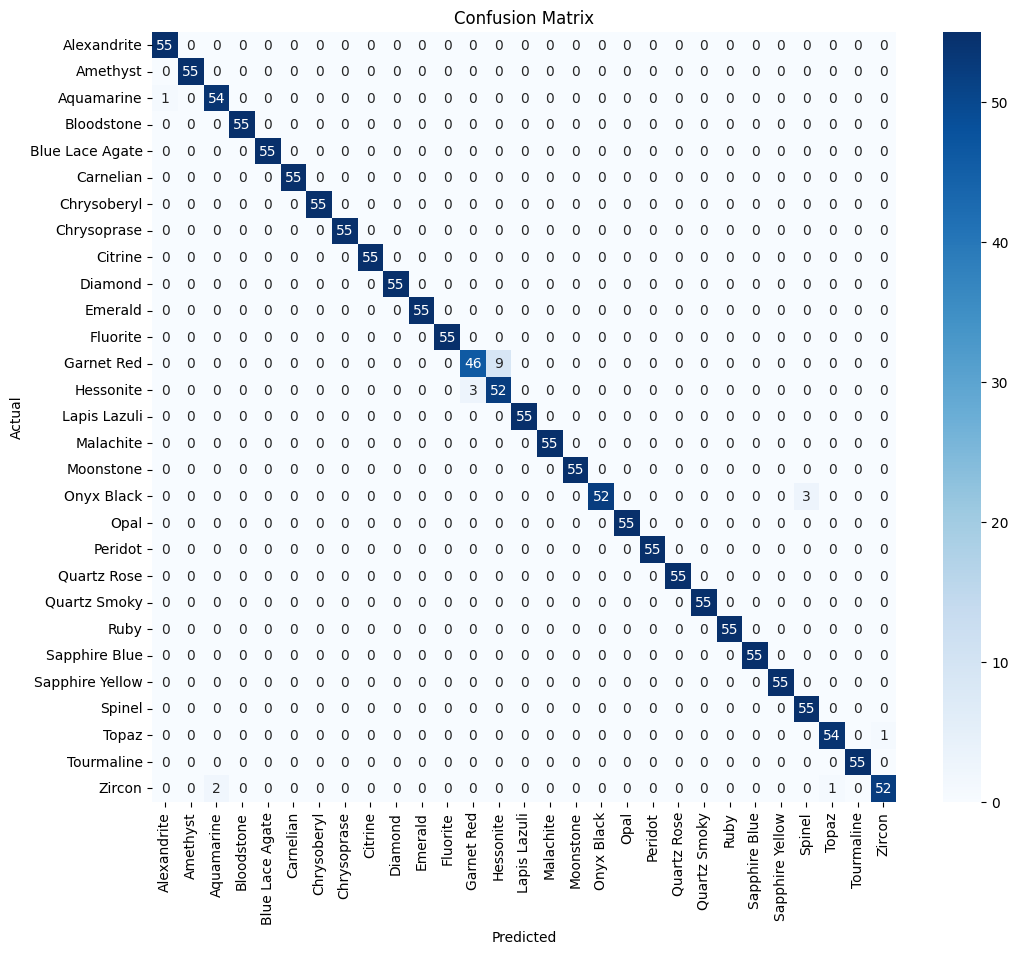

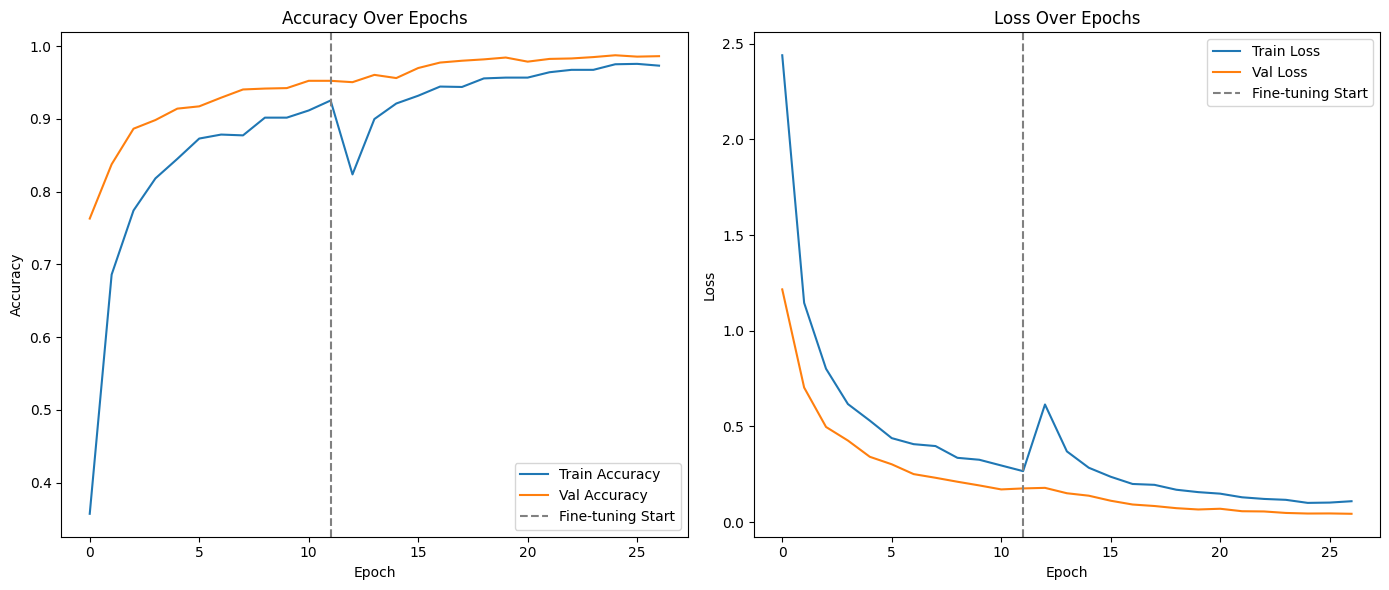

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot Accuracy & Loss
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(total_history['accuracy'], label='Train Accuracy')
plt.plot(total_history['val_accuracy'], label='Val Accuracy')
plt.axvline(x=epochs_stage1 - 1, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(total_history['loss'], label='Train Loss')
plt.plot(total_history['val_loss'], label='Val Loss')
plt.axvline(x=epochs_stage1 - 1, color='gray', linestyle='--', label='Fine-tuning Start')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
